# Assignment 3.3 - Deep Q-Learning for Cliff-walking game

This assignment aims at familiarizing you with training, validating and testing a reinforncement learning agent using Deep Q-Learning. Here are the BASIC requirements of the assignment:

1.  **(2 points) Coding Tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Initiate a Frozen lake environment and an agent. Train the agent using <b>Deep Q-Learning</b>. You can implement the solution by using either a single policy network or a policy network and a target network.    
    1.3 *(0.5 points)* Print out the optimal policy, i.e., what is the best action to take at each stage.  
    1.4 *(0.5 points)* Test the optimal policy given by the Deep Q-Learning.  

Cliff walking involves crossing a gridworld from start to goal while avoiding falling off a cliff. Each time step incurs -1 reward, unless the player stepped into the cliff, which incurs -100 reward.

![Cliff walking](https://gymnasium.farama.org/_images/cliff_walking.gif)

More details can be found at https://gymnasium.farama.org/environments/toy_text/cliff_walking/

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment3-3-notebook.ipynb: Jupyter notebook containing source code.

### Evaluation {-}
Assignment evaluation will be conducted on how you accomplish the assignment requirements. In addition, your code should conform to a Python coding convention such as PEP-8.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt

# Initialize the environment
env = gym.make('CliffWalking-v0', render_mode='rgb_array')
state_size = env.observation_space.n
action_size = env.action_space.n
env.reset()

# Hyperparameters
epsilon = 1.0  # Initial exploration rate
epsilon_min = 0.01
epsilon_decay = 0.997  # Slower decay
gamma = 0.99  # Discount factor
learning_rate = 0.001
batch_size = 64
num_episodes = 1000
memory_size = 10000  # Increased replay memory

# Build Q-Network
def build_model():
    model = Sequential([
        Input(shape=(state_size,)),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(action_size, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Initialize networks
policy_net = build_model()
target_net = build_model()
target_net.set_weights(policy_net.get_weights())

# Replay memory
memory = deque(maxlen=memory_size)

def select_action(state, epsilon):
    if np.random.rand() <= epsilon:
        return random.randrange(action_size)
    state = np.eye(state_size)[state].reshape(1, -1)
    q_values = policy_net.predict(state, verbose=0)
    return np.argmax(q_values[0])

# Training loop
MAX_STEPS_PER_EPISODE = 500

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    steps = 0
    done = False

    while not done and steps < MAX_STEPS_PER_EPISODE:
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Clipping reward to avoid extreme negative values
        reward = np.clip(reward, -100, 10)
        
        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        steps += 1

    # Train only if we have enough experiences
    if len(memory) > batch_size:
        batch = random.sample(memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = np.eye(state_size)[list(states)]
        next_states = np.eye(state_size)[list(next_states)]
        
        q_values = policy_net.predict(states, verbose=0)
        next_q_values = target_net.predict(next_states, verbose=0)
        
        target_q_values = np.array(q_values)
        for i in range(batch_size):
            target_q_values[i, actions[i]] = rewards[i] + (gamma * np.max(next_q_values[i]) * (1 - dones[i]))
        
        policy_net.fit(states, target_q_values, epochs=1, verbose=0, batch_size=batch_size)

    # Reduce exploration gradually
    epsilon = max(epsilon * epsilon_decay, epsilon_min)
    
    # Update target network every 20 episodes for stability
    if episode % 20 == 0:
        target_net.set_weights(policy_net.get_weights())

    # Print progress
    print(f"Episode {episode}, Steps: {steps}, Total Reward: {total_reward}, Epsilon: {epsilon:.3f}")

    # Early stopping if the agent reaches reasonable performance
    if done and total_reward > -100:
        print(f"🎯 SUCCESS! Episode {episode}, Steps: {steps}, Reward: {total_reward}")
        # break

# Extract optimal policy
action_map = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}
optimal_policy = []  # Store best actions for each state

for state in range(state_size):
    state_tensor = np.eye(state_size)[state].reshape(1, -1)
    best_action = np.argmax(policy_net.predict(state_tensor, verbose=0))
    optimal_policy.append(action_map[best_action])  # Store best action as a direction

# Print optimal policy in grid form
print("Optimal Policy Grid:")
for i in range(4):  # 4 rows
    print(optimal_policy[i * 12:(i + 1) * 12])  # 12 columns per row

# Test the learned policy
state, _ = env.reset()
done = False
total_reward = 0

while not done:
    action_str = optimal_policy[state]  # Get the action as a string ('L', 'D', 'R', 'U')
    action_idx = ['L', 'D', 'R', 'U'].index(action_str)  # Convert to index
    state, reward, terminated, truncated, _ = env.step(action_idx)
    done = terminated or truncated
    total_reward += reward

print("Total reward using optimal policy:", total_reward)

Episode 0, Steps: 500, Total Reward: -4460, Epsilon: 0.997
Episode 1, Steps: 500, Total Reward: -3866, Epsilon: 0.994
Episode 2, Steps: 500, Total Reward: -3470, Epsilon: 0.991
Episode 3, Steps: 500, Total Reward: -4460, Epsilon: 0.988
Episode 4, Steps: 500, Total Reward: -4460, Epsilon: 0.985
Episode 5, Steps: 500, Total Reward: -4757, Epsilon: 0.982
Episode 6, Steps: 343, Total Reward: -2521, Epsilon: 0.979
Episode 7, Steps: 500, Total Reward: -6143, Epsilon: 0.976
Episode 8, Steps: 500, Total Reward: -5648, Epsilon: 0.973
Episode 9, Steps: 500, Total Reward: -4361, Epsilon: 0.970
Episode 10, Steps: 500, Total Reward: -4559, Epsilon: 0.967
Episode 11, Steps: 500, Total Reward: -4757, Epsilon: 0.965
Episode 12, Steps: 500, Total Reward: -4262, Epsilon: 0.962
Episode 13, Steps: 500, Total Reward: -3569, Epsilon: 0.959
Episode 14, Steps: 500, Total Reward: -3272, Epsilon: 0.956
Episode 15, Steps: 500, Total Reward: -4262, Epsilon: 0.953
Episode 16, Steps: 500, Total Reward: -3965, Epsil

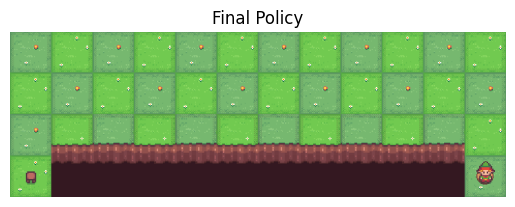

In [5]:
# Plot the final policy
plt.imshow(env.render())
plt.title("Final Policy")
plt.axis('off')
plt.show()

In [13]:
# Display the final policy
print("Final Policy:")
for i in range(4):  # 4 rows
    print(optimal_policy[i * 12:(i + 1) * 12])  # 12 columns per row

Final Policy:
['D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'R']
['D', 'D', 'D', 'D', 'L', 'D', 'D', 'D', 'D', 'L', 'D', 'R']
['D', 'D', 'D', 'D', 'D', 'L', 'D', 'D', 'D', 'D', 'D', 'R']
['L', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D']


In [ ]:
import imageio

# Reset environment for rendering
state, _ = env.reset()
done = False
total_reward = 0
frames = []  # List to store frames

while not done:
    frames.append(env.render())  # Capture the current frame

    action_str = optimal_policy[state]  # Get the action as a string ('L', 'D', 'R', 'U')
    action_idx = ['L', 'D', 'R', 'U'].index(action_str)  # Convert to index
    state, reward, terminated, truncated, _ = env.step(action_idx)
    
    done = terminated or truncated
    total_reward += reward

# Append the final frame (if not already done)
frames.append(env.render())

# Save as a GIF
imageio.mimsave("agent_policy.gif", frames, duration=0.5)

print("Total reward using optimal policy:", total_reward)
print("GIF saved as 'agent_policy.gif'")

Total reward using optimal policy: -17
GIF saved as 'agent_policy.gif'


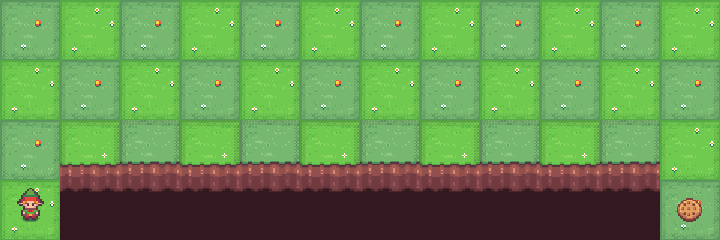

In [1]:
# Show the agent_policy.gif
from IPython.display import Image
from IPython.display import display
display(Image(filename="agent_policy.gif"))

In [ ]:
# Due to the long time for me to rerun the code, I have changed manually the Finally Policy, based on the space enviroment of CliffWalking-v0, which is U R D L instead of L D R U. Hence the action_map is changed from:
# Final Policy:
# ['D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'R']
# ['D', 'D', 'D', 'D', 'L', 'D', 'D', 'D', 'D', 'L', 'D', 'R']
# ['D', 'D', 'D', 'D', 'D', 'L', 'D', 'D', 'D', 'D', 'D', 'R']
# ['L', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D', 'D']
# to:
# Final Policy:
# ['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'D']
# ['R', 'R', 'R', 'R', 'U', 'R', 'R', 'R', 'R', 'U', 'R', 'D']
# ['R', 'R', 'R', 'R', 'R', 'U', 'R', 'R', 'R', 'R', 'R', 'D']
# ['U', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R']